### Hidden Markov Model

In [1]:
import numpy as np
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

In [2]:
# Set a random seed for reproducibility
np.random.seed(42)

# Define the simulation parameters
n_days = 365 # simulate one year
start_date = datetime(2024, 1, 1)

In [ ]:
# Define hidden states (0: Cold, 1: Moderate, 2: Warm)
states = [0, 1, 2]
n_states = len(states)

# Define transition probability matrix for the hidden Markov chain
transition_matrix = np.array([
    [0.80, 0.15, 0.05],  # from Cold, mostly stay Cold, sometimes go to Moderate
    [0.10, 0.80, 0.10],  # from Moderate, can transition to either Cold or Warm
    [0.05, 0.15, 0.80]   # from Warm, mostly stay Warm, sometimes to Moderate
])

In [ ]:
# State means and stds: [Temp, Humidity]
state_params = {
    0: {'mean': [30, 80], 'std': [5, 5]},   # Cold
    1: {'mean': [60, 60], 'std': [5, 5]},   # Moderate
    2: {'mean': [90, 40], 'std': [5, 5]}    # Warm
}

In [16]:
# Simulate hidden states over time using the transition matrix
# Simulate hidden states
states = [np.random.choice(n_states)]
for _ in range(1, n_days):
    states.append(np.random.choice(n_states, p=transition_matrix[states[-1]]))


In [19]:
# Simulate observations based on hidden states
observations = []
for state in states:
    mean, std = state_params[state]['mean'], state_params[state]['std']
    obs = np.random.normal(loc=mean, scale=std)
    observations.append(obs)

In [7]:
# Create a date range for the dataset
dates = [start_date + timedelta(days=i) for i in range(n_days)]

In [8]:
# Create a DataFrame to store the synthetic data
data = pd.DataFrame({
    'Date': dates,
    'Temperature': temperatures,
    'Humidity': humidities,
    'True_State': hidden_states
})

In [9]:
# Display the first few rows of the dataset
print("Sample of the simulated dataset:")
print(data.head())

Sample of the simulated dataset:
        Date  Temperature   Humidity  True_State
0 2024-01-01    62.196636  59.457511           1
1 2024-01-02    87.567836  41.037991           2
2 2024-01-03    94.424952  37.677351           2
3 2024-01-04    86.888814  38.222557           2
4 2024-01-05    64.760055  67.262751           1


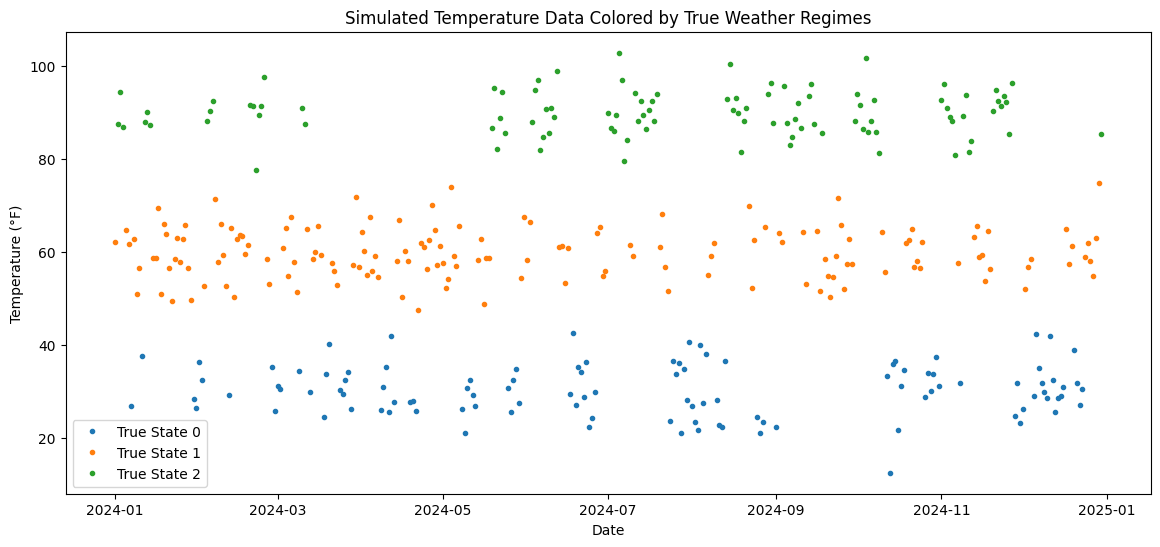

In [10]:
# Plot the temperature over time colored by the true hidden state
plt.figure(figsize=(14, 6))
for state in states:
    state_data = data[data['True_State'] == state]
    plt.plot(state_data['Date'], state_data['Temperature'], '.', label=f'True State {state}')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.title('Simulated Temperature Data Colored by True Weather Regimes')
plt.legend()
plt.show()

In [11]:
# Save the dataset to a CSV file
data.to_csv('synthetic_weather_data.csv', index=False)
print("Dataset saved to 'synthetic_weather_data.csv'")

Dataset saved to 'synthetic_weather_data.csv'


In [14]:
# Prepare the observations for the HMM (we use both Temperature and Humidity)
# hmmlearn expects a 2D array: (n_samples, n_features)
observations = data[['Temperature', 'Humidity']].values

# Initialize the Gaussian HMM with 3 states
model = hmm.GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=1000, random_state=42)

# Fit the model to the observations
model.fit(observations)

# Predict the hidden states using the trained model
predicted_states = model.predict(observations)



# Add the predicted states to the DataFrame
data['Predicted_State'] = predicted_states

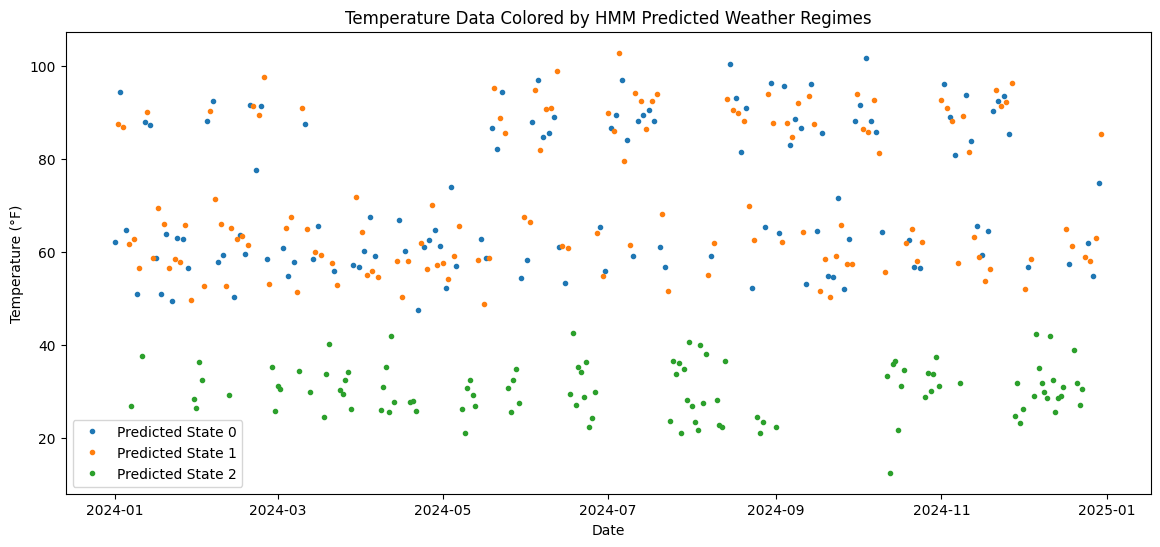

In [15]:
plt.figure(figsize=(14, 6))
for state in range(n_states):
    state_data = data[data['Predicted_State'] == state]
    plt.plot(state_data['Date'], state_data['Temperature'], '.', label=f'Predicted State {state}')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.title('Temperature Data Colored by HMM Predicted Weather Regimes')
plt.legend()
plt.show()


In [ ]:
# Compute raw confusion matrix (with permuted labels)
raw_cm = confusion_matrix(data['True_State'], data['Predicted_State'])

# Use Hungarian algorithm to find best label alignment
# The algorithm minimizes the cost, so we use -confusion_matrix to maximize matches
row_ind, col_ind = linear_sum_assignment(-raw_cm)

# Create a mapping from predicted label → true label
label_map = {pred_label: true_label for true_label, pred_label in zip(row_ind, col_ind)}

# Apply the mapping to predicted labels
data['Mapped_Predicted_State'] = data['Predicted_State'].map(label_map)

# Generate aligned confusion matrix
aligned_cm = confusion_matrix(data['True_State'], data['Mapped_Predicted_State'])

# Display the aligned confusion matrix
aligned_confusion_table = pd.crosstab(data['True_State'], data['Mapped_Predicted_State'],
                                      rownames=['True'], colnames=['Predicted'])
print("\nAligned Confusion Table (after label matching):")
print(aligned_confusion_table)


Aligned Confusion Table (after label matching):
Predicted    0   1   2
True                  
0          107   0   0
1            0  86  71
2            0  51  50
